In [2]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from lifelines import CoxPHFitter
import seaborn as sns

ModuleNotFoundError: No module named 'numpy'

In [ ]:
from utils.load_data import load_target_dataset
from utils.clinical_data_features import ClinicalDataFeatures
from utils.molecular_data_features import MolecularDataFeature

In [ ]:
target_df = load_target_dataset("data/target_train.csv")


# Clinical Data
df_cli = pd.read_csv("data/X_train/clinical_train.csv")
df_cli_eval = pd.read_csv("data/X_test/clinical_test.csv")

# Apply the process
cdf = ClinicalDataFeatures()

df_cli = cdf.process(df_cli)
df_cli_eval = cdf.process(df_cli_eval)


df_mol = pd.read_csv("data/X_train/molecular_train.csv")
df_mol_eval = pd.read_csv("data/X_test/molecular_test.csv")

mdf = MolecularDataFeature()

df_mol = mdf.process(df_mol)
df_eval_mol = mdf.process(df_mol_eval)

#We merge the processed molecular data with the clinical data
df = df_cli.merge(df_mol, on='ID', how='left')
#We fill NaN values with 0 for the new features
df = df.fillna(df.median(numeric_only=True))
df_eval = df_cli_eval.merge(df_mol_eval, on='ID', how='left')
#We fill NaN values with 0 for the new features
df_eval =df_eval.fillna(df.median(numeric_only=True))
#df.columns.to_series().to_csv("data/features.csv", index=False)

#We allign the rows of the df with the target_df
df = df[df['ID'].isin(target_df['ID'])]
#We drop the ID column as it is not needed anymore
df.drop(columns=['ID', 'CENTER'], inplace=True)
df_eval.drop(columns=['ID', 'CENTER'], inplace=True)

target_df = target_df.drop(columns=['ID'])
target_df["OS_STATUS"]=target_df["OS_STATUS"].astype(bool)

# Now split
X_train, X_test, y_train, y_test = train_test_split(df, target_df, test_size=0.3, random_state=42)

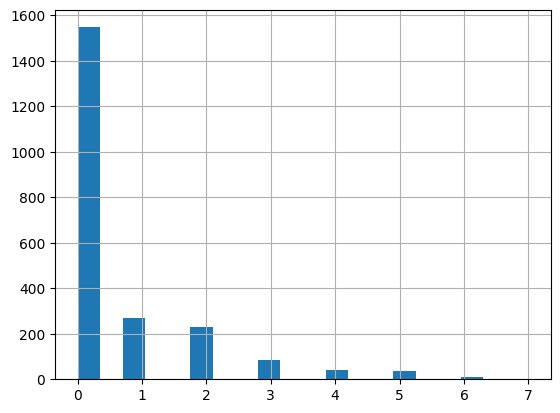

In [ ]:
# Exemple : dataframe df, colonne 'age'
X_train['total_abnormalities'].hist(bins=20)
plt.show()

In [ ]:
df_cox = pd.concat([df, target_df], axis=1)
#target_df = target_df[''].astype(int)

# Initialiser le modèle
cph = CoxPHFitter(penalizer=0.1)

# Ajuster le modèle sur toutes les colonnes sauf 'temps_survie' et 'decede' comme features
cph.fit(df_cox, duration_col = 'OS_YEARS', event_col='OS_STATUS')

# Afficher le résumé
cph.print_summary()


<lifelines.CoxPHFitter: fitted with 3173 total observations, 1573 right-censored observations>
             duration col = 'OS_YEARS'
                event col = 'OS_STATUS'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 3173
number of events observed = 1600
   partial log-likelihood = -11138.23
         time fit was run = 2025-10-31 09:42:25 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
BM_BLAST                    0.02      1.02      0.00            0.01            0.03                1.01                1.03
WBC                         0.00      1.00      0.00           -0.00            0.01                1.00                1.01
ANC                         0.00      1.00      0.01           -0.01            0.02                0.99                1.02
MONOCYTES                   0.01      1.01      0.01           -0.01            0.03                0.99                1.03
HB                         -0.12      0.89      0.01           -0.14           -0.09                0.87                0.91
PLT                        -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
46_chromo                  -0.16      0.85      0.07           -0.30           -0.02                0.74                0.98
has_deletion                0.13      1.14      0.08           -0.03            0.29                0.97                1.34
has_translocation           0.26      1.29      0.10            0.06            0.46                1.06                1.58
has_inversion               0.33      1.40      0.18           -0.01            0.68                0.99                1.97
has_addition                0.43      1.54      0.11            0.21            0.66                1.23                1.93
has_chr7_abnormal           0.10      1.10      0.16           -0.22            0.41                0.80                1.51
has_chr5_abnormal          -0.02      0.98      0.10           -0.22            0.18                0.80                1.20
has_trisomy8                0.01      1.01      0.10           -0.19            0.22                0.83                1.24
has_monosomy7               0.18      1.20      0.17           -0.15            0.51                0.86                1.66
has_del7q                  -0.00      1.00      0.20           -0.39            0.39                0.67                1.48
total_abnormalities         0.05      1.05      0.04           -0.03            0.13                0.97                1.14
has_high_risk_marker        0.11      1.11      0.09           -0.07            0.28                0.93                1.33
is_missing_cytogenetics     0.22      1.25      0.09            0.04            0.40                1.04                1.50
total_cell_count            0.00      1.00      0.00           -0.00            0.01                1.00                1.01
abnormal_cell_fraction_bin  0.02      1.02      0.01            0.00            0.04                1.00                1.04
total_mutations             0.08      1.08      0.02            0.04            0.11                1.04                1.12
effect_score                0.00      1.00      0.00           -0.00            0.01                1.00                1.01
max_VAF                     0.59      1.81      0.11            0.37            0.81                1.45                2.25
max_DEPTH                   0.00      1.00      0.00            0.00            0.00                1.00                1.00
HIGH_RISK                   0.07      1.07      0.04           -0.00            0.14                1.00                1.15
HOTSPOTS                    0.11      1.12      0.04            0

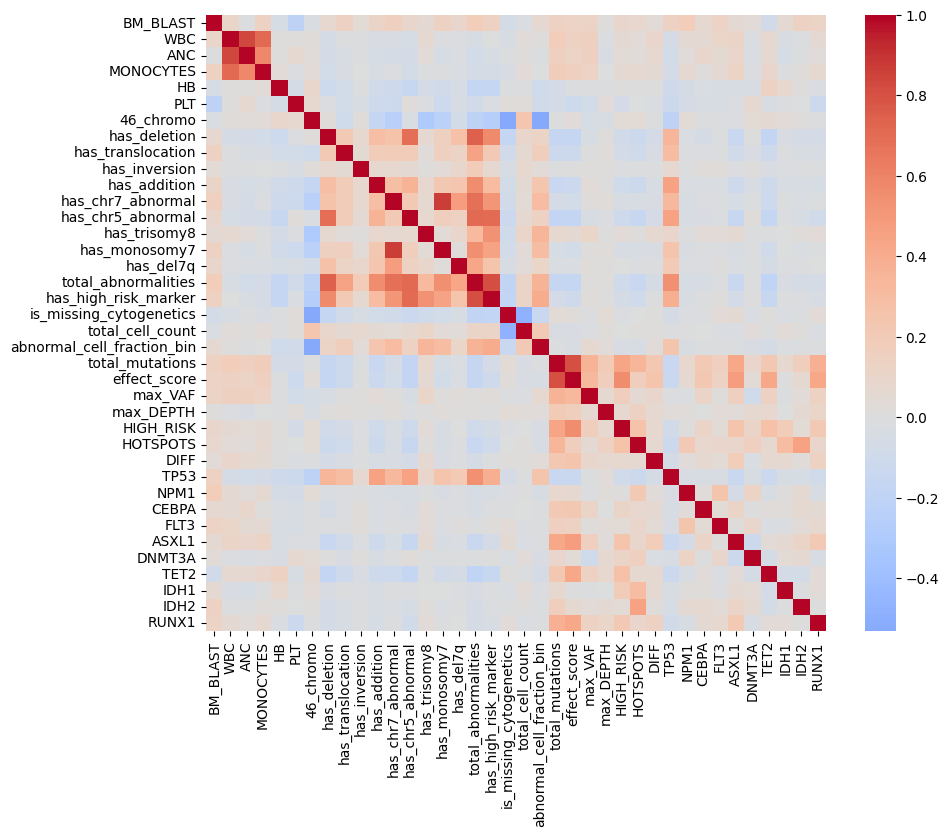

In [ ]:
corr = df_cox.drop(columns=["OS_YEARS","OS_STATUS"]).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()